# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [3]:
from sklearn.metrics import mean_squared_error

# 3.1) The random walk process

## 3.1.1) simulating a random walk process

In [4]:
np.random.seed(42)
random_walk = np.cumsum(
    st.norm.rvs(size=1_000)
)

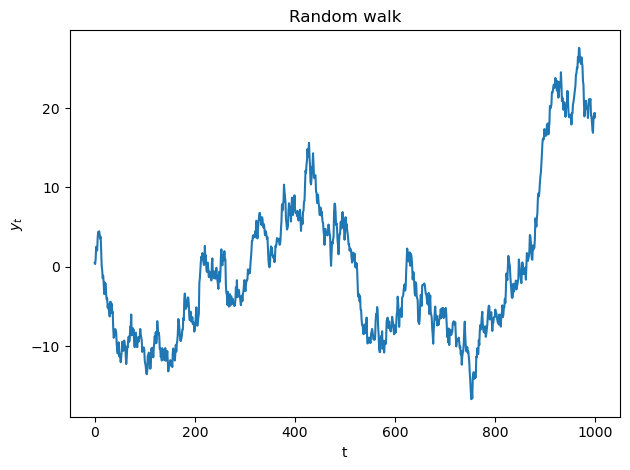

In [5]:
fig, ax = plt.subplots()
ax.plot(random_walk)
ax.set_xlabel('t')
ax.set_ylabel('$y_t$')
ax.set_title('Random walk')
plt.tight_layout()
plt.show()

# 3.2) Identifying a random walk

## 3.2.2) Testing for stationarity

In [6]:
np.random.seed(42)
y = [0]
z = [0]
for i in range(1, 1001):
    y.append(0.5 * y[i-1] + st.norm.rvs(size=1))
    z.append(z[i-1] + st.norm.rvs(size=1))

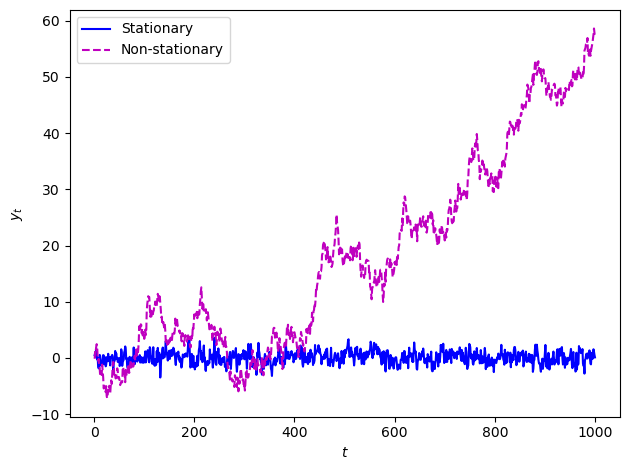

In [7]:
fig, ax = plt.subplots()
ax.plot(np.arange(1, 1001), y[1:], 'b-', label='Stationary')
ax.plot(np.arange(1, 1001), z[1:], 'm--', label="Non-stationary")
ax.legend()
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.tight_layout()
plt.show()

## 3.2.4) Putting it all together

In [8]:
adf_result = adfuller(random_walk)

In [9]:
adf_result

(-0.9659524876918764,
 0.7654789696692577,
 0,
 999,
 {'1%': -3.4369127451400474,
  '5%': -2.864437475834273,
  '10%': -2.568312754566378},
 2735.4178367833106)

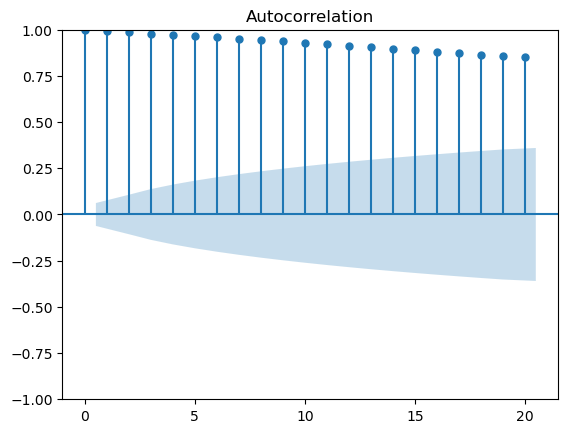

In [10]:
fig, ax = plt.subplots()
plot_acf(random_walk, lags=20, ax=ax)
plt.show()

In [11]:
random_walk.shape

(1000,)

In [12]:
diff_random_walk = np.diff(random_walk, n=1)

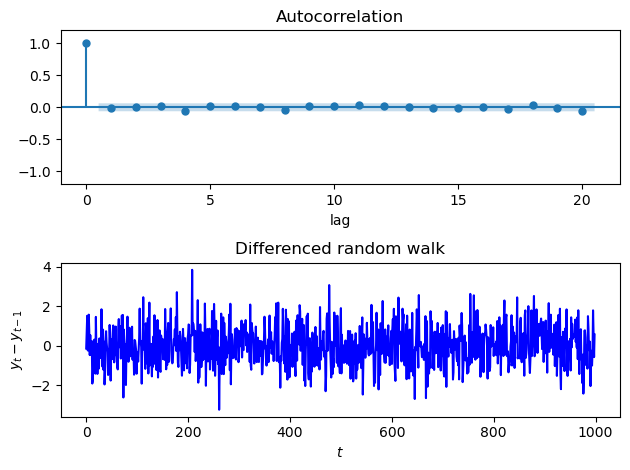

In [13]:
fig, ax = plt.subplots(nrows=2, ncols=1)
plot_acf(diff_random_walk, lags=20, ax=ax[0])
ax[0].set_xlabel('lag')
ax[0].set_ylim([-1.2, 1.2])

ax[1].plot(np.arange(diff_random_walk.shape[0]), diff_random_walk, 'b-')
ax[1].set_xlabel('$t$')
ax[1].set_ylabel('$y_t - y_{t-1}$')
ax[1].set_title('Differenced random walk')

plt.tight_layout()
plt.show()

In [14]:
adf_diff_random_walk = adfuller(diff_random_walk)
adf_diff_random_walk

(-31.789310857560594,
 0.0,
 0,
 998,
 {'1%': -3.4369193380671, '5%': -2.864440383452517, '10%': -2.56831430323573},
 2732.1890358304863)

## 3.2.5) Is googl a random walk?

In [15]:
df_googl = pd.read_csv("data/GOOGL.csv")
df_googl.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-04-27,1292.000000,1294.099976,1265.060059,1270.859985,1270.859985,2209300
1,2020-04-28,1283.199951,1284.760010,1230.380005,1232.589966,1232.589966,4035000
2,2020-04-29,1345.000000,1360.150024,1326.729980,1342.180054,1342.180054,5417900
3,2020-04-30,1331.359985,1350.000000,1321.500000,1346.699951,1346.699951,2792100
4,2020-05-01,1324.089966,1351.430054,1309.660034,1317.319946,1317.319946,2443600


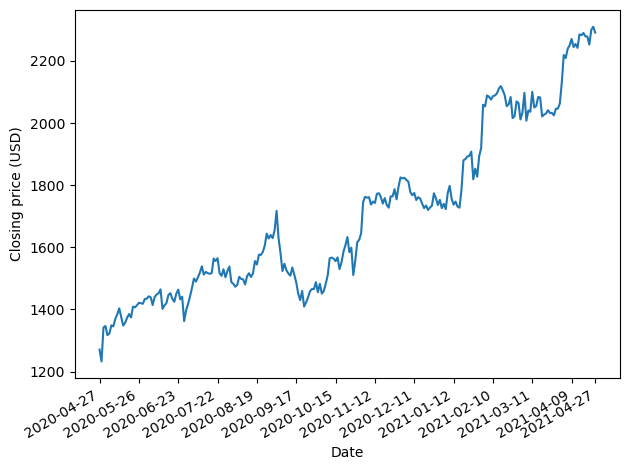

In [16]:
fig, ax = plt.subplots()
ax.plot(df_googl['Date'], df_googl['Close'])
ax.set_xlabel('Date')
ax.set_ylabel('Closing price (USD)')
ax.set_xticks(
    [df_googl.loc[i, 'Date'] for i in range(0, df_googl.shape[0], 20)] + [df_googl.iloc[df_googl.shape[0]-1, 0]]
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [17]:
googl_adfuller = adfuller(df_googl['Close'])

In [18]:
googl_adfuller

(0.16025048664771302,
 0.9699419435913057,
 8,
 244,
 {'1%': -3.457437824930831,
  '5%': -2.873459364726563,
  '10%': -2.573122099570008},
 2292.5903585999613)

In [19]:
diff_close = np.diff(df_googl.Close)

In [20]:
googl_diff_adfuller = adfuller(diff_close)

In [21]:
googl_diff_adfuller

(-5.303439704295234,
 5.3865309614545585e-06,
 7,
 244,
 {'1%': -3.457437824930831,
  '5%': -2.873459364726563,
  '10%': -2.573122099570008},
 2281.5968988816794)

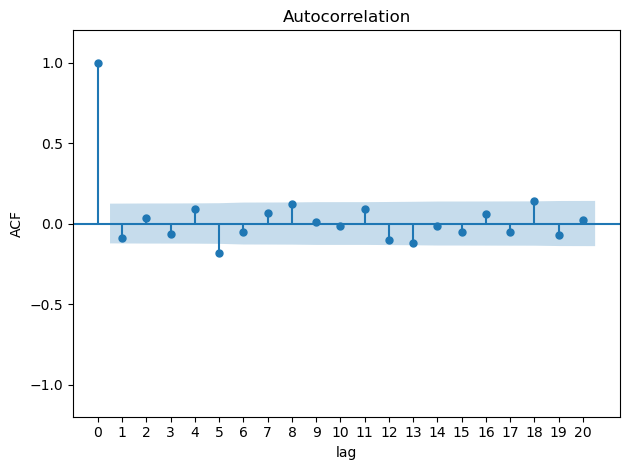

In [22]:
fig, ax = plt.subplots()
plot_acf(diff_close, lags=20, ax=ax)
ax.set_xlabel('lag')
ax.set_ylabel('ACF')
ax.set_ylim([-1.2, 1.2])
ax.set_xticks(np.arange(0, 21, 1))

plt.tight_layout()
plt.show()

# 3.3) Forecasting a random walk

In [23]:
random_walk.shape

(1000,)

In [24]:
df = pd.DataFrame({'value': random_walk})
train = df.loc[:800].copy()
test = df.loc[800:].copy()

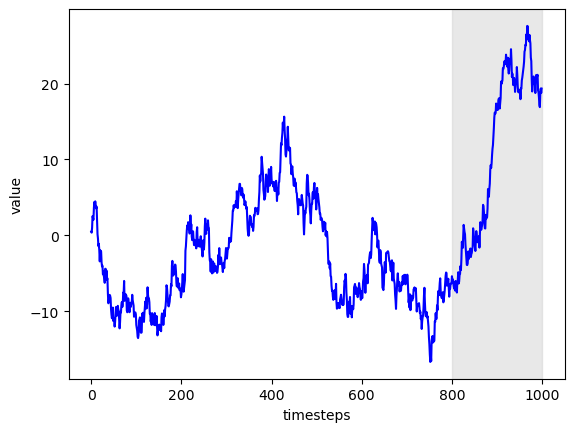

In [25]:
fig, ax = plt.subplots()
ax.plot(df.index, df.value, 'b-')
ax.set_xlabel('timesteps')
ax.set_ylabel('value')
ax.axvspan(800, 1000, color='lightgray', alpha=0.5)

plt.show()

In [26]:
test.loc[:, "pred_mean"] = np.mean(train.value)

In [27]:
test.head()

,value,pred_mean
800,-5.379950,-3.183238
801,-5.895994,-3.183238
802,-5.799873,-3.183238
803,-6.262149,-3.183238
804,-6.696645,-3.183238


In [28]:
test['pred_last'] = train.value.iloc[-1]

In [29]:
test

,value,pred_mean,pred_last
800,-5.379950,-3.183238,-5.37995
801,-5.895994,-3.183238,-5.37995
802,-5.799873,-3.183238,-5.37995
803,-6.262149,-3.183238,-5.37995
804,-6.696645,-3.183238,-5.37995
...,...,...,...
995,16.892123,-3.183238,-5.37995
996,18.689809,-3.183238,-5.37995
997,19.330652,-3.183238,-5.37995
998,18.759473,-3.183238,-5.37995


In [30]:
slope = (train.loc[799, 'value'] - train.loc[0, 'value']) / (800 - 1)
slope

-0.008529346056640628

In [31]:
test['pred_drift'] = slope * (np.arange(801, 1001, 1) - 1) + train.loc[0, 'value']


In [32]:
test.head()

,value,pred_mean,pred_last,pred_drift
800,-5.379950,-3.183238,-5.37995,-6.326763
801,-5.895994,-3.183238,-5.37995,-6.335292
802,-5.799873,-3.183238,-5.37995,-6.343821
803,-6.262149,-3.183238,-5.37995,-6.352351
804,-6.696645,-3.183238,-5.37995,-6.360880


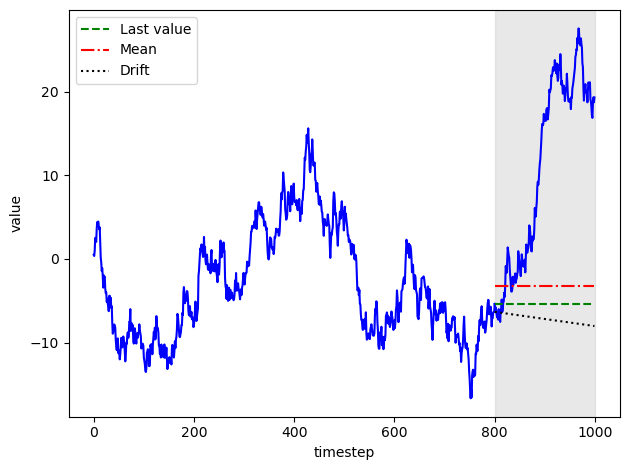

In [33]:
fig, ax = plt.subplots()
ax.plot(train['value'], 'b-')
ax.plot(test['value'], 'b-')
ax.plot(test['pred_last'], 'g--', label='Last value')
ax.plot(test['pred_mean'], 'r-.', label='Mean')
ax.plot(test['pred_drift'], 'k:', label='Drift')
ax.axvspan(800, 1000, color='lightgray', alpha=0.5)
ax.set_xlabel('timestep')
ax.set_ylabel('value')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

In [34]:
mse = {
    'mean': mean_squared_error(test['value'], test['pred_mean']),
    'last': mean_squared_error(test['value'], test['pred_last']),
    'drift': mean_squared_error(test['value'], test['pred_drift']),
}

In [35]:
mse

{'mean': 326.580513209793,
 'last': 393.6034941889509,
 'drift': 465.9076036601397}

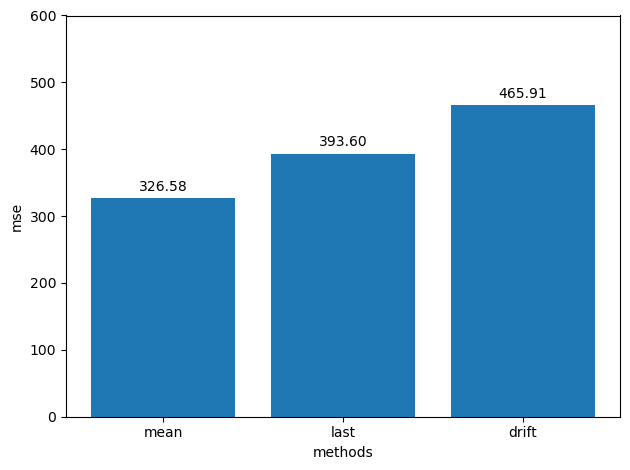

In [37]:
fig, ax = plt.subplots()
barras = ax.bar(mse.keys(), mse.values())
ax.bar_label(barras, fmt='%.2f', padding=3)
ax.set_ylim([0, 600])
ax.set_xlabel('methods')
ax.set_ylabel('mse')
plt.tight_layout()
plt.show()

## 3.3.2) Forecasting the next timestep

In [38]:
df_shift = df.shift(periods=1)

In [39]:
df_shift.head()

,value
0,NaN
1,0.496714
2,0.358450
3,1.006138
4,2.529168


In [40]:
df.shape

(1000, 1)

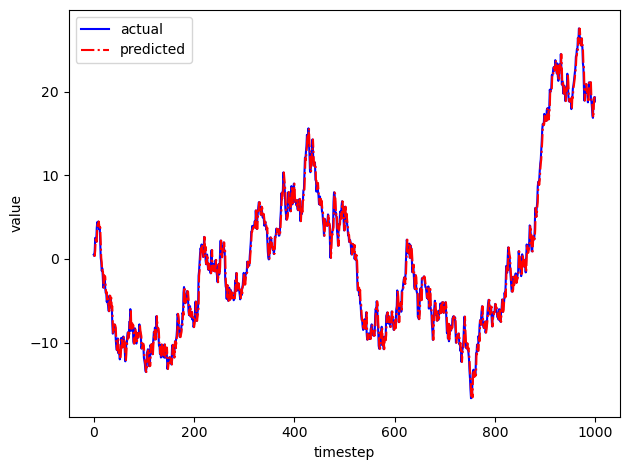

In [46]:
fig, ax = plt.subplots()
ax.plot(df, 'b-', label='actual')
ax.plot(df_shift, 'r-.', label='predicted')
ax.legend(loc='best')
ax.set_xlabel('timestep')
ax.set_ylabel('value')
plt.tight_layout()
plt.show()

In [43]:
mean_squared_error(test['value'], df_shift[800:])

0.9256876651440581